### 다항 회귀

- 직선의 형태인 회귀선으로 잘 예측되지 않는 부분을 2차, 3차 곡선을 이용하는 회귀 분석
- 새로운 파생변수가 생성되는 과정
    - 0차항: y절편
    - 1차항: 원래 가지고 있던 변수들을 그대로 유지
    - 2차항
        - 자기 복제: 각 변수를 제곱한 값이 생성
        - 상호 작용: 서로 다른 변수끼리 곱한 항이 생성

In [1]:
import pandas as pd

In [2]:
cereal = pd.read_csv('../data/cereal.csv')
cereal.head(3)

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,100% Bran,N,C,70,4,1,130,10.0,5.0,6,280,25,3,1.0,0.33,68.402973
1,100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8,135,0,3,1.0,1.00,33.983679
2,All-Bran,K,C,70,4,1,260,9.0,7.0,5,320,25,3,1.0,0.33,59.425505


In [3]:
cereal.info()

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      77 non-null     str    
 1   mfr       77 non-null     str    
 2   type      77 non-null     str    
 3   calories  77 non-null     int64  
 4   protein   77 non-null     int64  
 5   fat       77 non-null     int64  
 6   sodium    77 non-null     int64  
 7   fiber     77 non-null     float64
 8   carbo     77 non-null     float64
 9   sugars    77 non-null     int64  
 10  potass    77 non-null     int64  
 11  vitamins  77 non-null     int64  
 12  shelf     77 non-null     int64  
 13  weight    77 non-null     float64
 14  cups      77 non-null     float64
 15  rating    77 non-null     float64
dtypes: float64(5), int64(8), str(3)
memory usage: 9.8 KB


In [4]:
cereal.describe()

,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
count,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000
mean,106.883117,2.545455,1.012987,159.675325,2.151948,14.597403,6.922078,96.077922,28.246753,2.207792,1.029610,0.821039,42.665705
std,19.484119,1.094790,1.006473,83.832295,2.383364,4.278956,4.444885,71.286813,22.342523,0.832524,0.150477,0.232716,14.047289
min,50.000000,1.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000,1.000000,0.500000,0.250000,18.042851
25%,100.000000,2.000000,0.000000,130.000000,1.000000,12.000000,3.000000,40.000000,25.000000,1.000000,1.000000,0.670000,33.174094
50%,110.000000,3.000000,1.000000,180.000000,2.000000,14.000000,7.000000,90.000000,25.000000,2.000000,1.000000,0.750000,40.400208
75%,110.000000,3.000000,2.000000,210.000000,3.000000,17.000000,11.000000,120.000000,25.000000,3.000000,1.000000,1.000000,50.828392
max,160.000000,6.000000,5.000000,320.000000,14.000000,23.000000,15.000000,330.000000,100.000000,3.000000,1.500000,1.500000,93.704912


In [6]:
# -1이 존재하는 데이터가 어떤 것들인가?

flag = cereal['sugars'] < 0

cereal.loc[flag, ]

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
57,Quaker Oatmeal,Q,H,100,5,2,0,2.7,-1.0,-1,110,0,1,1.0,0.67,50.828392


In [9]:
# carbo, sugars, potass column에서 0보다 작은 값들을 모두 확인
# column을 3개 선택하여 0보다 작다 조건식을 사용하고 any() → loc[]

flag2 = (cereal[['carbo', 'sugars', 'potass']] < 0).any(axis = 1)

cereal.loc[flag2, ]

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
4,Almond Delight,R,C,110,2,2,200,1.0,14.0,8,-1,25,3,1.0,0.75,34.384843
20,Cream of Wheat (Quick),N,H,100,3,0,80,1.0,21.0,0,-1,0,2,1.0,1.00,64.533816
57,Quaker Oatmeal,Q,H,100,5,2,0,2.7,-1.0,-1,110,0,1,1.0,0.67,50.828392


In [11]:
df = cereal.loc[~flag2, ]

In [12]:
df.describe()

,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
count,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000
mean,107.027027,2.513514,1.000000,162.364865,2.175676,14.729730,7.108108,98.513514,29.054054,2.216216,1.030811,0.821622,42.371787
std,19.843893,1.075802,1.006826,82.769787,2.423391,3.891675,4.359111,70.878681,22.294352,0.832067,0.153416,0.235715,14.033712
min,50.000000,1.000000,0.000000,0.000000,0.000000,5.000000,0.000000,15.000000,0.000000,1.000000,0.500000,0.250000,18.042851
25%,100.000000,2.000000,0.000000,135.000000,0.250000,12.000000,3.000000,41.250000,25.000000,1.250000,1.000000,0.670000,32.449210
50%,110.000000,2.500000,1.000000,180.000000,2.000000,14.500000,7.000000,90.000000,25.000000,2.000000,1.000000,0.750000,40.253086
75%,110.000000,3.000000,1.000000,217.500000,3.000000,17.000000,11.000000,120.000000,25.000000,3.000000,1.000000,1.000000,50.520611
max,160.000000,6.000000,5.000000,320.000000,14.000000,23.000000,15.000000,330.000000,100.000000,3.000000,1.500000,1.500000,93.704912


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

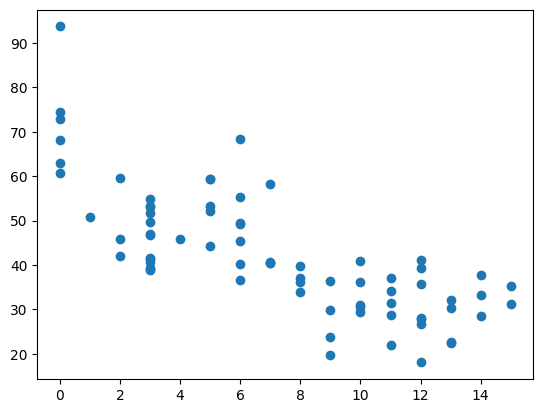

In [14]:
plt.scatter(
    df['sugars'],
    df['rating']
)

plt.show()

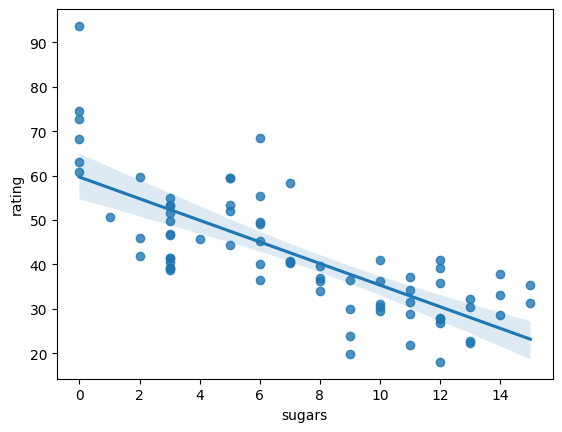

In [15]:
# 산점도에 회귀선을 추가하여 그래프 생성

sns.regplot(
    data = df, x = 'sugars', y = 'rating'
)

plt.show()

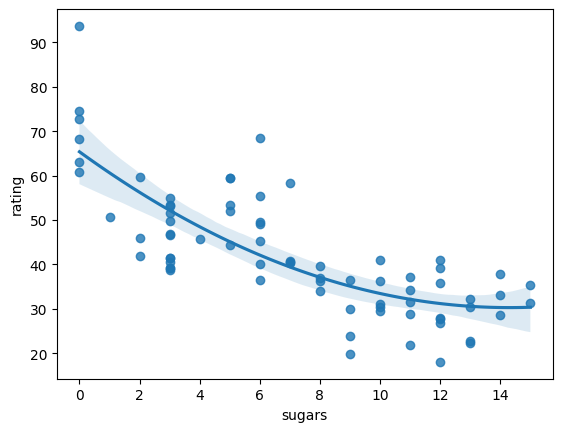

In [ ]:
# 다항 회귀선

sns.regplot(
    data = df, x = 'sugars', y = 'rating', order = 2
)

plt.show()

In [19]:
df.iloc[:, 3:].corr().iloc[-1, ]

calories   -0.693785
protein     0.467162
fat        -0.405050
sodium     -0.383012
fiber       0.603411
carbo       0.055941
sugars     -0.755955
potass      0.415782
vitamins   -0.214481
shelf       0.051040
weight     -0.300461
cups       -0.222504
rating      1.000000
Name: rating, dtype: float64

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

In [25]:
x = df[['sugars']]
y = df['rating']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

In [26]:
lr = LinearRegression()
lr.fit(X_train, y_train)

pred = lr.predict(X_test)
print(mean_absolute_error(y_test, pred))

7.469662633513549


In [27]:
# 다항 회귀를 이용하기 위해 컬럼 추가 → 단일독립변수이므로 제곱항 추가
# n차원 다항 조건을 생성하기 위한 기능 로드

from sklearn.preprocessing import PolynomialFeatures

In [28]:
# class 생성

poly_reg = PolynomialFeatures()

# 데이터를 fit하고 transform

X_train_poly = poly_reg.fit_transform(X_train)
X_test_poly = poly_reg.transform(X_test)

In [29]:
lr.fit(X_train_poly, y_train)

pred_2 = lr.predict(X_test_poly)

print(mean_absolute_error(y_test, pred_2))

6.203734788707707


In [ ]:
# 칼로리, 당분 데이터를 독립변수로 사용해 다항 회귀

X = df[['calories', 'sugars']]
y = df['rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42
)

X_train_poly = poly_reg.fit_transform(X_train)
X_test_poly = poly_reg.transform(X_test)

lr.fit(X_train_poly, y_train)

pred_3 = lr.predict(X_test_poly)

print(mean_absolute_error(y_test, pred_3))

7.301706460179354


In [47]:
# df에서 문자열로 이루어진 데이터 컬럼은 모두 제외하고, 선형회귀 방식으로 mae 값과 다중회귀 방식으로 mae 값의 차이 확인
# train:test = 7:3

# df1 = df.iloc[:, 3:]

# select_dtypes: 특정 데이터 type의 컬럼을 선택
# 각각의 type들을 []로 묶어서 사용
# 숫자형 type만 보고 싶을 때는 number 사용
# df1 = df.select_dtypes(['int', 'float'])

df1 = df.select_dtypes('number')
df1

,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,70,4,1,130,10.0,5.0,6,280,25,3,1.0,0.33,68.402973
1,120,3,5,15,2.0,8.0,8,135,0,3,1.0,1.00,33.983679
2,70,4,1,260,9.0,7.0,5,320,25,3,1.0,0.33,59.425505
3,50,4,0,140,14.0,8.0,0,330,25,3,1.0,0.50,93.704912
5,110,2,2,180,1.5,10.5,10,70,25,1,1.0,0.75,29.509541
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,110,2,1,250,0.0,21.0,3,60,25,3,1.0,0.75,39.106174
73,110,1,1,140,0.0,13.0,12,25,25,2,1.0,1.00,27.753301
74,100,3,1,230,3.0,17.0,3,115,25,1,1.0,0.67,49.787445
75,100,3,1,200,3.0,17.0,3,110,25,1,1.0,1.00,51.592193


In [59]:
# 단항회귀

X = df1.drop('rating', axis=1)
y = df1['rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

lr.fit(X_train, y_train)

pred_4 = lr.predict(X_test)

print('MAE:', mean_absolute_error(y_test, pred_4))
print('R2 score:', r2_score(y_test, pred_4))
print()
print('회귀계수:', lr.coef_, ', 절편:', lr.intercept_)

MAE: 2.485564877783576e-07
R2 score: 0.9999999999999994

회귀계수: [-2.22724164e-01  3.27317388e+00 -1.69140799e+00 -5.44927023e-02
  3.44347979e+00  1.09245096e+00 -7.24895133e-01 -3.39933508e-02
 -5.12119692e-02 -8.52424532e-10 -5.43229923e-07  7.83331469e-09] , 절편: 54.927184195979635


In [61]:
# 다항회귀

X_train_poly = poly_reg.fit_transform(X_train)
X_test_poly = poly_reg.transform(X_test)

lr.fit(X_train_poly, y_train)

pred_5 = lr.predict(X_test_poly)

print('MAE:', mean_absolute_error(y_test, pred_5))
print('R2 score:', r2_score(y_test, pred_5))
print()
print('회귀계수:', lr.coef_, ', 절편:', lr.intercept_)

MAE: 1.5367907775506442
R2 score: 0.9651980903622579

회귀계수: [-1.37425390e-13 -1.22262232e-01 -7.58588905e-04 -7.19850075e-04
 -2.67613770e-02  5.72843186e-03  3.32861733e-02 -5.13877489e-02
  9.01450111e-03 -6.46222689e-02  1.04175469e-02  5.18446653e-04
 -1.71242268e-03  7.06455418e-04  2.35126479e-02 -4.94295437e-02
 -1.79483752e-03  5.11451133e-03 -5.06396812e-03 -1.86834465e-03
  3.41084426e-04  1.86273632e-03  1.66980664e-03  8.14993044e-02
  9.15310727e-03  3.78713488e-03  4.87115543e-02  1.42899827e-02
  4.00312217e-02 -3.46606102e-02 -6.32725586e-02  1.76640449e-02
 -9.50910997e-02  5.17429731e-02  2.53708245e-03  4.69796374e-03
 -4.25430271e-02  1.68102668e-02 -2.31388447e-03  4.81894447e-03
  8.96387236e-02 -1.02790554e-02  1.68383776e-02  1.78982907e-02
  1.07205460e-03  7.06017291e-05  5.18997889e-06  4.78608212e-03
  6.59291152e-03  7.68749655e-03 -1.79780695e-04  7.91532203e-04
 -7.63794105e-03 -2.94051818e-02 -8.68183619e-03  2.29330514e-02
  2.34566081e-02 -1.99253823e-

In [50]:
X_test_poly

array([[  1.    , 110.    ,   2.    , ...,   1.    ,   0.75  ,   0.5625],
       [  1.    , 110.    ,   2.    , ...,   1.    ,   0.75  ,   0.5625],
       [  1.    , 110.    ,   3.    , ...,   1.    ,   0.5   ,   0.25  ],
       ...,
       [  1.    , 110.    ,   1.    , ...,   1.    ,   1.    ,   1.    ],
       [  1.    , 110.    ,   1.    , ...,   1.    ,   1.    ,   1.    ],
       [  1.    , 110.    ,   1.    , ...,   1.    ,   1.33  ,   1.7689]],
      shape=(23, 91))